In [23]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm
# 日銀の政策変更日
boj_events_typed = {
    '2006-07-14': '利上げ',
    '2007-02-21': '利上げ',
    '2008-10-31': '利下げ・緩和',
    '2008-12-19': '利下げ・緩和',
    '2013-04-04': '利下げ・緩和',
    '2014-10-31': '利下げ・緩和',
    '2016-01-29': '利下げ・緩和',
    '2016-09-21': '利下げ・緩和',
    '2022-12-20': '利上げ',
    '2023-07-28': '利上げ',
    '2023-10-31': '利上げ',
    '2024-03-19': '利上げ',
    '2024-07-31': '利上げ',
    '2025-01-24': '利上げ',
    '2025-12-19': '利上げ',
}

boj_events = list(boj_events_typed.keys())
print(f"イベント総数: {len(boj_events)}")

# FOMCの政策変更日
fomc_events = [
    '2024-09-18',  # 4年ぶり利下げ（-0.5%）
    '2024-11-07',  # 追加利下げ（-0.25%）
    '2024-12-18',  # 追加利下げ（-0.25%）
]

print("日銀イベント日:", boj_events)
print("FOMCイベント日:", fomc_events)

イベント総数: 15
日銀イベント日: ['2006-07-14', '2007-02-21', '2008-10-31', '2008-12-19', '2013-04-04', '2014-10-31', '2016-01-29', '2016-09-21', '2022-12-20', '2023-07-28', '2023-10-31', '2024-03-19', '2024-07-31', '2025-01-24', '2025-12-19']
FOMCイベント日: ['2024-09-18', '2024-11-07', '2024-12-18']


In [24]:
# 日経平均とドル円のデータを取得
nikkei = yf.download('^N225', start='2006-01-01', end='2025-12-31')
usdjpy = yf.download('JPY=X', start='2006-01-01', end='2025-12-31')

print("日経平均：", nikkei.shape)
print("ドル円：", usdjpy.shape)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

日経平均： (4893, 5)
ドル円： (5186, 5)


In [25]:
# 終値から日次リターンを計算
nikkei_ret = nikkei['Close'].pct_change().dropna()
usdjpy_ret = usdjpy['Close'].pct_change().dropna()

print("日経平均リターン（最初の5行）:")
print(nikkei_ret.head())

日経平均リターン（最初の5行）:
Ticker         ^N225
Date                
2006-01-05  0.003901
2006-01-06  0.000173
2006-01-10 -0.018496
2006-01-11  0.014837
2006-01-12  0.004987


In [26]:
# イベント前後5営業日のリターンを抽出する関数
def get_event_window(returns, event_date, window=5):
    event_date = pd.Timestamp(event_date)
    idx = returns.index.get_indexer([event_date], method='nearest')[0]
    start = max(0, idx - window)
    end = min(len(returns), idx + window + 1)
    window_data = returns.iloc[start:end].copy()
    window_data.index = range(-window, len(window_data) - window)
    return window_data

# 日銀イベントで試す
test = get_event_window(nikkei_ret, '2024-03-19')
print(test)

Ticker     ^N225
-5     -0.000592
-4     -0.002617
-3      0.002879
-2     -0.002570
-1      0.026682
0       0.006622
1       0.020300
2       0.001783
3      -0.011600
4      -0.000398
5       0.009028


In [27]:
# 日銀全イベントのリターンをまとめる
boj_results = {}
for event in boj_events:
    boj_results[event] = get_event_window(nikkei_ret, event)

# FOMC全イベントのリターンをまとめる
fomc_results = {}
for event in fomc_events:
    fomc_results[event] = get_event_window(nikkei_ret, event)

print("完了")

完了


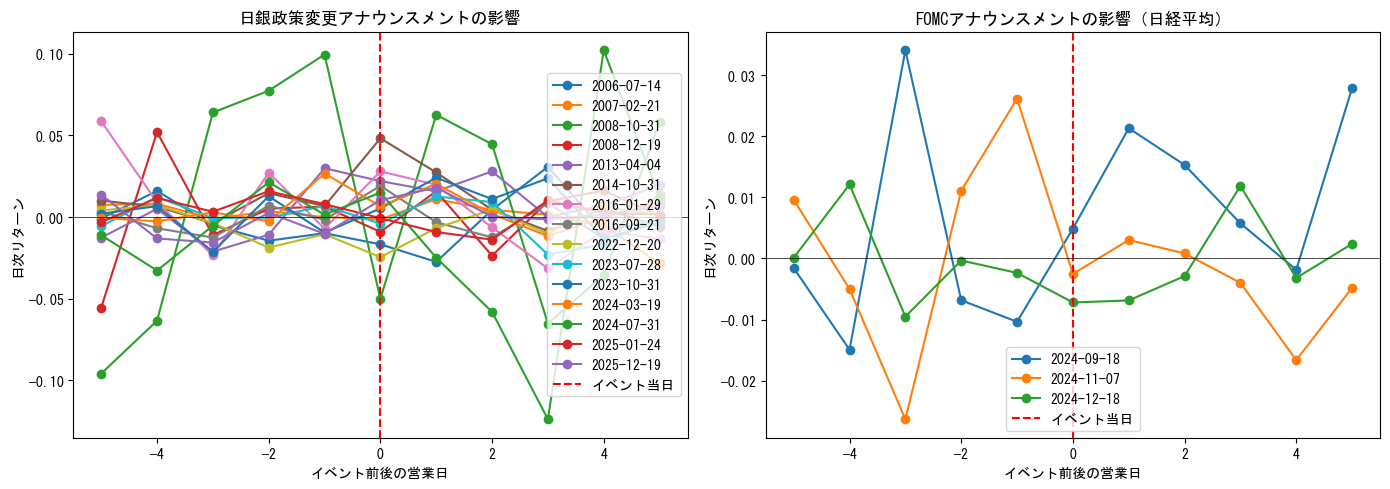

In [28]:
plt.rcParams['font.family'] = 'MS Gothic'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 日銀イベントのプロット
for event, data in boj_results.items():
    axes[0].plot(data.index, data.values, marker='o', label=event)
axes[0].axvline(x=0, color='red', linestyle='--', label='イベント当日')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_title('日銀政策変更アナウンスメントの影響')
axes[0].set_xlabel('イベント前後の営業日')
axes[0].set_ylabel('日次リターン')
axes[0].legend()

# FOMCイベントのプロット
for event, data in fomc_results.items():
    axes[1].plot(data.index, data.values, marker='o', label=event)
axes[1].axvline(x=0, color='red', linestyle='--', label='イベント当日')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title('FOMCアナウンスメントの影響（日経平均）')
axes[1].set_xlabel('イベント前後の営業日')
axes[1].set_ylabel('日次リターン')
axes[1].legend()

plt.tight_layout()
plt.show()

In [29]:
# イベント前の[-120, -10]日を推定期間として正常リターンを計算
def get_normal_return(returns, event_date, est_start=-120, est_end=-10):
    event_date = pd.Timestamp(event_date)
    idx = returns.index.get_indexer([event_date], method='nearest')[0]
    start = max(0, idx + est_start)
    end = max(0, idx + est_end)
    estimation_window = returns.iloc[start:end]
    normal_return = estimation_window.mean().values[0]
    return normal_return

# 各イベントの正常リターンを確認
for event in boj_events:
    nr = get_normal_return(nikkei_ret, event)
    print(f"{event}の正常リターン: {nr:.6f}")

2006-07-14の正常リターン: -0.000237
2007-02-21の正常リターン: 0.000678
2008-10-31の正常リターン: -0.003989
2008-12-19の正常リターン: -0.004371
2013-04-04の正常リターン: 0.003311
2014-10-31の正常リターン: 0.000380
2016-01-29の正常リターン: -0.001434
2016-09-21の正常リターン: 0.000156
2022-12-20の正常リターン: 0.000625
2023-07-28の正常リターン: 0.001456
2023-10-31の正常リターン: 0.000779
2024-03-19の正常リターン: 0.001771
2024-07-31の正常リターン: 0.001261
2025-01-24の正常リターン: 0.000723
2025-12-19の正常リターン: 0.002582


In [30]:
def get_car(returns, event_date, window=5):
    # 正常リターン
    normal_ret = get_normal_return(returns, event_date)
    
    # イベント前後のリターン
    event_window = get_event_window(returns, event_date, window)
    
    # 異常リターン = 実際のリターン - 正常リターン
    abnormal_ret = event_window - normal_ret
    
    # 累積異常リターン
    car = abnormal_ret.cumsum()
    
    return abnormal_ret, car

# 全イベントで計算
print("=== 日銀イベント ===")
for event in boj_events:
    ar, car = get_car(nikkei_ret, event)
    print(f"\n{event}")
    print(f"当日異常リターン: {ar.loc[0].values[0]:.4f}")
    print(f"5日累積異常リターン(CAR): {car.loc[5].values[0]:.4f}")

=== 日銀イベント ===

2006-07-14
当日異常リターン: -0.0165
5日累積異常リターン(CAR): -0.0311

2007-02-21
当日異常リターン: -0.0021
5日累積異常リターン(CAR): -0.0079

2008-10-31
当日異常リターン: -0.0462
5日累積異常リターン(CAR): 0.1398

2008-12-19
当日異常リターン: -0.0047
5日累積異常リターン(CAR): 0.0548

2013-04-04
当日異常リターン: 0.0187
5日累積異常リターン(CAR): 0.0465

2014-10-31
当日異常リターン: 0.0479
5日累積異常リターン(CAR): 0.1006

2016-01-29
当日異常リターン: 0.0294
5日累積異常リターン(CAR): 0.0682

2016-09-21
当日異常リターン: 0.0190
5日累積異常リターン(CAR): 0.0001

2022-12-20
当日異常リターン: -0.0252
5日累積異常リターン(CAR): -0.0576

2023-07-28
当日異常リターン: -0.0055
5日累積異常リターン(CAR): -0.0246

2023-10-31
当日異常リターン: 0.0045
5日累積異常リターン(CAR): 0.0295

2024-03-19
当日異常リターン: 0.0049
5日累積異常リターン(CAR): 0.0300

2024-07-31
当日異常リターン: 0.0137
5日累積異常リターン(CAR): -0.1183

2025-01-24
当日異常リターン: -0.0014
5日累積異常リターン(CAR): 0.0181

2025-12-19
当日異常リターン: 0.0077
5日累積異常リターン(CAR): -0.0159


In [31]:
import numpy as np
from scipy import stats

def get_ttest(returns, event_date, window=5):
    # 正常リターンの推定期間を取得
    event_date = pd.Timestamp(event_date)
    idx = returns.index.get_indexer([event_date], method='nearest')[0]
    start = max(0, idx - 120)
    end = max(0, idx - 10)
    estimation_window = returns.iloc[start:end]
    
    # 標準誤差の計算
    std = estimation_window.std().values[0]
    n = window * 2 + 1  # イベントウィンドウの日数
    std_err = std * np.sqrt(n)
    
    # CARの取得
    _, car = get_car(returns, event_date, window)
    car_value = car.loc[window].values[0]
    
    # t統計量
    t_stat = car_value / std_err
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=len(estimation_window)-1))
    
    return car_value, t_stat, p_value

print("=== 日銀イベント t検定結果 ===")
for event in boj_events:
    car, t, p = get_ttest(nikkei_ret, event)
    sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    print(f"{event}: CAR={car:.4f}, t={t:.3f}, p={p:.3f} {sig}")

=== 日銀イベント t検定結果 ===
2006-07-14: CAR=-0.0311, t=-0.652, p=0.516 
2007-02-21: CAR=-0.0079, t=-0.278, p=0.782 
2008-10-31: CAR=0.1398, t=1.578, p=0.117 
2008-12-19: CAR=0.0548, t=0.447, p=0.656 
2013-04-04: CAR=0.0465, t=1.077, p=0.284 
2014-10-31: CAR=0.1006, t=3.341, p=0.001 ***
2016-01-29: CAR=0.0682, t=1.183, p=0.239 
2016-09-21: CAR=0.0001, t=0.003, p=0.998 
2022-12-20: CAR=-0.0576, t=-1.465, p=0.146 
2023-07-28: CAR=-0.0246, t=-0.804, p=0.423 
2023-10-31: CAR=0.0295, t=0.832, p=0.407 
2024-03-19: CAR=0.0300, t=0.805, p=0.423 
2024-07-31: CAR=-0.1183, t=-3.318, p=0.001 ***
2025-01-24: CAR=0.0181, t=0.255, p=0.799 
2025-12-19: CAR=-0.0159, t=-0.362, p=0.718 


In [32]:
print("=== FOMCイベント t検定結果 ===")
for event in fomc_events:
    car, t, p = get_ttest(nikkei_ret, event)
    sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    print(f"{event}: CAR={car:.4f}, t={t:.3f}, p={p:.3f} {sig}")

=== FOMCイベント t検定結果 ===
2024-09-18: CAR=0.0757, t=1.131, p=0.261 
2024-11-07: CAR=-0.0112, t=-0.158, p=0.875 
2024-12-18: CAR=-0.0096, t=-0.132, p=0.895 


In [33]:
# ドル円のリターン計算（既に取得済み）
usdjpy_ret = usdjpy['Close'].pct_change().dropna()

print("=== 日銀イベント t検定結果（ドル円） ===")
for event in boj_events:
    car, t, p = get_ttest(usdjpy_ret, event)
    sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    print(f"{event}: CAR={car:.4f}, t={t:.3f}, p={p:.3f} {sig}")

print("\n=== FOMCイベント t検定結果（ドル円） ===")
for event in fomc_events:
    car, t, p = get_ttest(usdjpy_ret, event)
    sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    print(f"{event}: CAR={car:.4f}, t={t:.3f}, p={p:.3f} {sig}")

=== 日銀イベント t検定結果（ドル円） ===
2006-07-14: CAR=0.0085, t=0.473, p=0.637 
2007-02-21: CAR=-0.0242, t=-1.876, p=0.063 *
2008-10-31: CAR=0.0091, t=0.166, p=0.869 
2008-12-19: CAR=0.0056, t=0.096, p=0.923 
2013-04-04: CAR=0.0339, t=1.494, p=0.138 
2014-10-31: CAR=0.0689, t=5.496, p=0.000 ***
2016-01-29: CAR=0.0037, t=0.231, p=0.818 
2016-09-21: CAR=-0.0057, t=-0.207, p=0.836 
2022-12-20: CAR=-0.0282, t=-1.077, p=0.284 
2023-07-28: CAR=0.0163, t=0.783, p=0.435 
2023-10-31: CAR=-0.0089, t=-0.528, p=0.599 
2024-03-19: CAR=0.0305, t=1.685, p=0.095 *
2024-07-31: CAR=-0.0858, t=-5.044, p=0.000 ***
2025-01-24: CAR=-0.0229, t=-1.017, p=0.312 
2025-12-19: CAR=-0.0035, t=-0.196, p=0.845 

=== FOMCイベント t検定結果（ドル円） ===
2024-09-18: CAR=0.0017, t=0.074, p=0.941 
2024-11-07: CAR=0.0173, t=0.736, p=0.463 
2024-12-18: CAR=0.0446, t=1.750, p=0.083 *


In [34]:
# 全イベントのCARを収集
all_cars = []
for event in boj_events:
    try:
        _, car = get_car(nikkei_ret, event)
        all_cars.append(car.loc[5].values[0])
    except:
        print(f"スキップ: {event}")

# 平均CARのt検定
all_cars = np.array(all_cars)
t_stat, p_value = stats.ttest_1samp(all_cars, 0)

print(f"イベント数: {len(all_cars)}")
print(f"平均CAR: {np.mean(all_cars):.4f}")
print(f"t統計量: {t_stat:.3f}")
print(f"p値: {p_value:.3f}")
sig = "***" if p_value < 0.01 else "**" if p_value < 0.05 else "*" if p_value < 0.1 else "有意でない"
print(f"有意性: {sig}")

イベント数: 15
平均CAR: 0.0155
t統計量: 0.939
p値: 0.364
有意性: 有意でない


In [35]:
# 方向別にCARを収集
cars_hike = []    # 利上げ
cars_ease = []    # 利下げ・緩和

for event, etype in boj_events_typed.items():
    try:
        _, car = get_car(nikkei_ret, event)
        car_val = car.loc[5].values[0]
        if etype == '利上げ':
            cars_hike.append(car_val)
        else:
            cars_ease.append(car_val)
    except:
        print(f"スキップ: {event}")

# 利上げイベントの検定
cars_hike = np.array(cars_hike)
t_hike, p_hike = stats.ttest_1samp(cars_hike, 0)

# 緩和イベントの検定
cars_ease = np.array(cars_ease)
t_ease, p_ease = stats.ttest_1samp(cars_ease, 0)

print("=== 利上げイベント ===")
print(f"イベント数: {len(cars_hike)}")
print(f"平均CAR: {np.mean(cars_hike):.4f}")
print(f"t統計量: {t_hike:.3f}")
print(f"p値: {p_hike:.3f}")
sig = "***" if p_hike < 0.01 else "**" if p_hike < 0.05 else "*" if p_hike < 0.1 else "有意でない"
print(f"有意性: {sig}")

print("\n=== 緩和イベント ===")
print(f"イベント数: {len(cars_ease)}")
print(f"平均CAR: {np.mean(cars_ease):.4f}")
print(f"t統計量: {t_ease:.3f}")
print(f"p値: {p_ease:.3f}")
sig = "***" if p_ease < 0.01 else "**" if p_ease < 0.05 else "*" if p_ease < 0.1 else "有意でない"
print(f"有意性: {sig}")

=== 利上げイベント ===
イベント数: 9
平均CAR: -0.0197
t統計量: -1.256
p値: 0.245
有意性: 有意でない

=== 緩和イベント ===
イベント数: 6
平均CAR: 0.0683
t統計量: 3.496
p値: 0.017
有意性: **


In [36]:
# 2013-04-04を除外した緩和イベントで再検定
cars_ease_robust = []

for event, etype in boj_events_typed.items():
    if etype == '利下げ・緩和' and event != '2013-04-04':
        try:
            _, car = get_car(nikkei_ret, event)
            car_val = car.loc[5].values[0]
            cars_ease_robust.append(car_val)
        except:
            print(f"スキップ: {event}")

cars_ease_robust = np.array(cars_ease_robust)
t_robust, p_robust = stats.ttest_1samp(cars_ease_robust, 0)

print("=== 緩和イベント（異次元緩和除外） ===")
print(f"イベント数: {len(cars_ease_robust)}")
print(f"平均CAR: {np.mean(cars_ease_robust):.4f}")
print(f"t統計量: {t_robust:.3f}")
print(f"p値: {p_robust:.3f}")
sig = "***" if p_robust < 0.01 else "**" if p_robust < 0.05 else "*" if p_robust < 0.1 else "有意でない"
print(f"有意性: {sig}")

# 参考：2013-04-04単体のCAR
_, car_qqe = get_car(nikkei_ret, '2013-04-04')
print(f"\n参考・異次元緩和単体のCAR: {car_qqe.loc[5].values[0]:.4f}")

=== 緩和イベント（異次元緩和除外） ===
イベント数: 5
平均CAR: 0.0727
t統計量: 3.116
p値: 0.036
有意性: **

参考・異次元緩和単体のCAR: 0.0465
